<a href="https://colab.research.google.com/github/JuanJGalindo/SpinesAI_Direct/blob/main/HNN_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Regularized Least Squares Regression**

###**Model**
Given $\mathbb{X} \in \mathbb{R}^{n \times d}$ the feature matrix and $\mathbb{y} \in \mathbb{R}^{n \times 1}$ the predictions vector, we propose the linear model:

$$\mathbb{y} = \mathbb{X}\alpha,$$ where $\alpha \in \mathbb{R}^{d \times 1}$.

---

###**Loss Function**
$$\mathcal{L}(\alpha|\mathbb{X},\mathbb{y})=\lVert \mathbb{y}-\mathbb{X}\alpha \rVert_2^2 + \lambda\lVert \alpha \rVert_2^2$$

---

###**Optimization Objective**
Minimize the loss function such that:
$$\alpha^*=\text{argmin}_\alpha[\mathcal{L}(\alpha|\mathbb{X},\mathbb{y})]=(\mathbb{X}^{\mathsf{T}}\mathbb{X}+\lambda\mathbb{I}_d)^{-1}\mathbb{X}^{\mathsf{T}}\mathbb{y}$$

Initial Weights:
[-0.51874864  1.226758    0.62548053 -0.91168475]
Initial Bias: [0.]



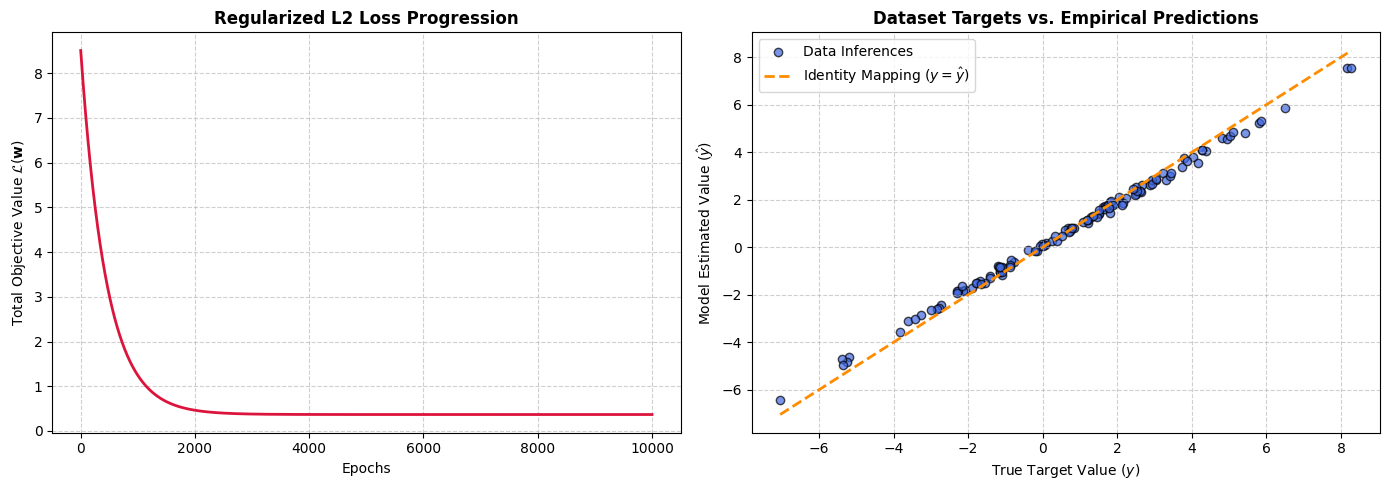

In [24]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Ensure deterministic execution for verification and hardware initialization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# ==========================================
# 1. SYNTHETIC DATA GENERATION
# ==========================================
N, d = 120, 4
X = torch.randn(N, d, device=device)

# Define underlying target function parameters
true_w = torch.tensor([[2.5], [-1.2], [0.5], [0.0]], device=device)
true_b = torch.tensor([[0.75]], device=device)

# Compute target vector and introduce Gaussian observation noise
y = X @ true_w + true_b + torch.randn(N, 1, device=device) * 0.15

# ==========================================
# 2. PARAMETER INITIALIZATION
# ==========================================
# Explicitly instantiate parameters as tracking leaf nodes in the autograd graph
weights = torch.randn(d, 1, device=device, requires_grad=True)
bias = torch.zeros(1, 1, device=device, requires_grad=True)

# Optimization Hyperparameters
learning_rate = 1e-3
lamda = 0.1  # Regularization scaling coefficient
epochs = int(1e4)

# Loss History
loss_history = []

# FIX: Added .cpu() before .numpy() to move data back to host memory
print(f"Initial Weights:\n{weights.detach().cpu().numpy().flatten()}")
print(f"Initial Bias: {bias.detach().cpu().numpy().flatten()}\n")

# ==========================================
# 3. OPTIMIZATION LOOP
# ==========================================
for epoch in range(epochs):
    # Forward Pass: Compute mathematical model projections
    predictions = X @ weights + bias

    # Mathematical Term 1: Data Fidelity (MSE)
    residuals = predictions - y
    mse_loss = (1.0 / (2.0 * N)) * torch.sum(residuals ** 2)

    # Mathematical Term 2: L2 Regularization Penalty (Excluding Bias)
    l2_penalty = (lamda / 2.0) * torch.sum(weights ** 2)

    # Objective Function
    total_loss = mse_loss + l2_penalty
    loss_history.append(total_loss.item())

    # Backward Pass: Evaluate analytical vector derivatives via Autograd
    total_loss.backward()

    # Gradient Update Step (Enclosing in no_grad to prevent graph accumulation)
    with torch.no_grad():
        # Gradient Descent Step: w = w - eta * grad
        weights -= learning_rate * weights.grad
        bias -= learning_rate * bias.grad

        # Explicitly flush out parameter gradients before the subsequent epoch
        weights.grad.zero_()
        bias.grad.zero_()

# Final evaluation pass for visualization
with torch.no_grad():
    final_predictions = X @ weights + bias

# ==========================================
# 4. DIAGNOSTIC VISUALIZATION
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Convergence
ax[0].plot(range(1, epochs + 1), loss_history, color='crimson', lw=2)
ax[0].set_title("Regularized L2 Loss Progression", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Total Objective Value $\\mathcal{L}(\\mathbf{w})$")
ax[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Alignment / Prediction Accuracy
# Tensors explicitly moved back to host CPU via .cpu() for plotting
ax[1].scatter(y.cpu().numpy(), final_predictions.cpu().numpy(), color='royalblue', alpha=0.7, edgecolors='k', label="Data Inferences")
ideal_line = [y.min().item(), y.max().item()]
ax[1].plot(ideal_line, ideal_line, color='darkorange', linestyle='--', lw=2, label="Identity Mapping ($y = \\hat{y}$)")
ax[1].set_title("Dataset Targets vs. Empirical Predictions", fontsize=12, fontweight='bold')
ax[1].set_xlabel("True Target Value ($y$)")
ax[1].set_ylabel("Model Estimated Value ($\\hat{y}$)")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#**Regression Multi-Layer Perceptron (Regressive MLP)**
###**Model**
Given $\mathbb{X} \in \mathbb{R}^{n \times d_0}$ the feature matrix, an $L$-layer Multi-Layer Perceptron maps inputs to continuous predictions through a parameterized cascade of affine transformations and non-linear activations.

Let $\boldsymbol{\Theta} = \{\mathbb{W}^{(l)}, \mathbb{b}^{(l)}\}_{l=1}^L$ represent the set of network parameters. The forward propagation for each layer $l \in \{1, \dots, L\}$ is expressed as:$$\mathbb{Z}^{(l)} = \mathbb{A}^{(l-1)}\mathbb{W}^{(l)} + \mathbf{1}_n(\mathbb{b}^{(l)})^{\mathsf{T}}$$$$\mathbb{A}^{(l)} = \sigma^{(l)}(\mathbb{Z}^{(l)}),$$where $\mathbb{A}^{(0)} = \mathbb{X}$, $\mathbb{W}^{(l)} \in \mathbb{R}^{d_{l-1} \times d_l}$ is the weight matrix, $\mathbb{b}^{(l)} \in \mathbb{R}^{d_l \times 1}$ is the bias vector, and $\sigma^{(l)}(\cdot)$ is an element-wise activation function.

For a regression task, the output layer activation is the identity mapping ($\sigma^{(L)}(\mathbb{Z}^{(L)}) = \mathbb{Z}^{(L)}$), yielding the network prediction matrix:$$\hat{\mathbb{Y}} = \mathbb{A}^{(L)} \in \mathbb{R}^{n \times d_L}$$
  
---

###**Loss Function**
Given $\mathbb{Y} \in \mathbb{R}^{n \times d_L}$ the true target matrix, the empirical Mean Squared Error loss function is:$$\mathcal{L}(\boldsymbol{\Theta}|\mathbb{X},\mathbb{Y}) = \frac{1}{2n} \lVert \mathbb{Y} - \hat{\mathbb{Y}} \rVert_{\text{2}}^2$$

---

###**Optimization Objective**
Minimize the loss function using first-order gradient descent via the backpropagation algorithm such that:$$\boldsymbol{\Theta}^* = \text{argmin}_{\boldsymbol{\Theta}} [\mathcal{L}(\boldsymbol{\Theta}|\mathbb{X},\mathbb{Y})]$$The parameter sets are updated iteratively using the generalized delta rule sensitivity matrices $\mathbb{D}^{(l)} = \frac{\partial \mathcal{L}}{\partial \mathbb{Z}^{(l)}} \in \mathbb{R}^{n \times d_l}$:$$\mathbb{W}^{(l)} \leftarrow \mathbb{W}^{(l)} - \eta \left(\mathbb{A}^{(l-1)\mathsf{T}}\mathbb{D}^{(l)}\right), \quad \mathbb{b}^{(l)} \leftarrow \mathbb{b}^{(l)} - \eta \left(\mathbb{D}^{(l)\mathsf{T}}\mathbf{1}_n\right),$$where the recursive error propagation scales from the output boundary state:$$\mathbb{D}^{(L)} = \frac{1}{n}(\hat{\mathbb{Y}} - \mathbb{Y}) \quad \text{and} \quad \mathbb{D}^{(l)} = \left(\mathbb{D}^{(l+1)}\mathbb{W}^{(l+1)\mathsf{T}}\right) \odot \sigma'^{(l)}(\mathbb{Z}^{(l)})$$

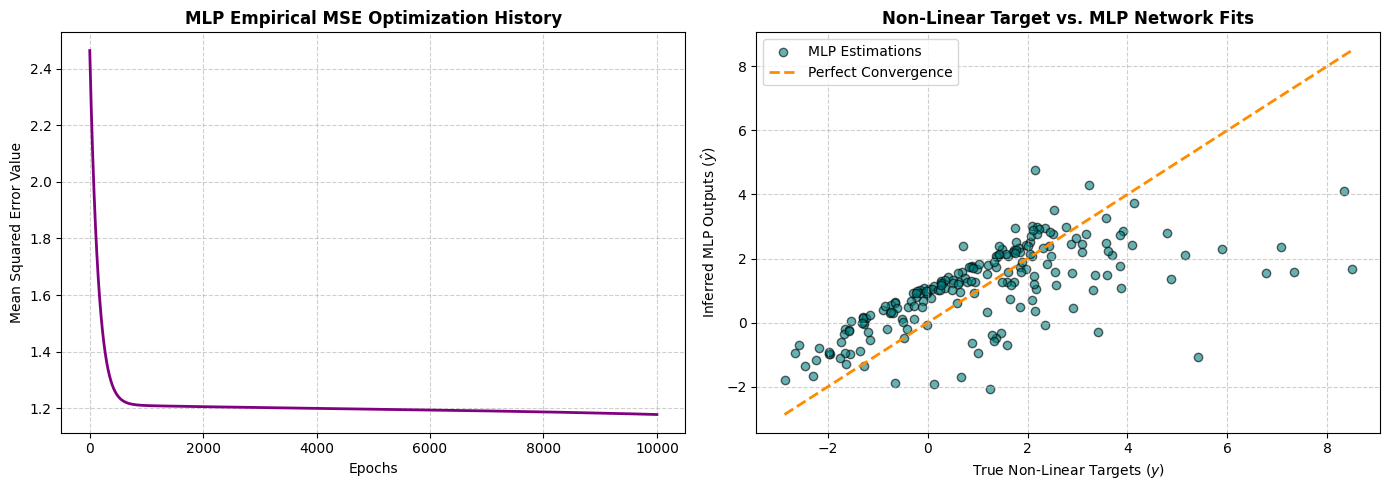

In [25]:
# Fix seeds for exact numeric replicability
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================================
# 1. GENERATE NON-LINEAR SYNTHETIC DATASET
# =====================================================================
N, d_in = 200, 3
X = torch.randn(N, d_in, device=device)

# Target generated via non-linear combination: y = sin(x_0) * 2 + (x_1)^2 - 0.5 * x_2
y = torch.sin(X[:, [0]]) * 2.0 + (X[:, [1]])**2 - 0.5 * X[:, [2]]

# =====================================================================
# 2. STRUCTURAL CONFIGURATION & PARAMETER INITIALIZATION
# =====================================================================
d_hidden = 256   # Dimension of Hidden Layer (h)
d_out = 1      # Dimension of Regression Output Layer

# Layer 1 Parameters (Input -> Hidden)
W1 = torch.randn(d_hidden, d_in, device=device) * 0.1
b1 = torch.zeros(d_hidden, 1, device=device)

# Layer 2 Parameters (Hidden -> Output)
W2 = torch.randn(d_out, d_hidden, device=device) * 0.1
b2 = torch.zeros(d_out, 1, device=device)

# Optimization Constants
learning_rate = 1e-3
epochs = int(1e4)

# Loss History
loss_history = []

# Non-linear Hidden Activation: Use torch functions instead of numpy to stay on device
def tanh(z):
    return torch.tanh(z)

def tanh_derivative(a):
    # Derivative expressed in terms of the activated output variable: 1 - tanh(a)**2
    return 1.0 - torch.pow(torch.tanh(a), 2)

# =====================================================================
# 3. MANUAL OPTIMIZATION LOOP (BATCH GRADIENT DESCENT)
# =====================================================================
# Transpose inputs to match column-vector math format: (d, N)
X_batch = X.t()
y_batch = y.t()

for epoch in range(epochs):
    # --- A. FORWARD PROPAGATION PASS ---
    Z1 = torch.matmul(W1, X_batch) + b1
    A1 = tanh(Z1)

    Z2 = torch.matmul(W2, A1) + b2
    A2 = Z2

    residuals = A2 - y_batch
    loss = (1.0 / (2.0 * N)) * torch.sum(residuals ** 2)
    loss_history.append(loss.item())

    # --- B. MANUAL BACKPROPAGATION PASS ---
    delta_2 = (1.0 / N) * residuals
    delta_1 = torch.matmul(W2.t(), delta_2) * tanh_derivative(Z1)

    dW2 = torch.matmul(delta_2, A1.t())
    db2 = torch.sum(delta_2, dim=1, keepdim=True)

    dW1 = torch.matmul(delta_1, X_batch.t())
    db1 = torch.sum(delta_1, dim=1, keepdim=True)

    # --- C. FIRST-ORDER GRADIENT DESCENT UPDATE ---
    with torch.no_grad():
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

# =====================================================================
# 4. DIAGNOSTIC VISUALIZATION
# =====================================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(1, epochs + 1), loss_history, color='purple', lw=2)
ax[0].set_title("MLP Empirical MSE Optimization History", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Mean Squared Error Value")
ax[0].grid(True, linestyle='--', alpha=0.6)

y_cpu = y_batch.cpu().numpy().flatten()
pred_cpu = A2.detach().cpu().numpy().flatten()

ax[1].scatter(y_cpu, pred_cpu, color='teal', alpha=0.6, edgecolors='k', label="MLP Estimations")
ideal_line = [y_cpu.min(), y_cpu.max()]
ax[1].plot(ideal_line, ideal_line, color='darkorange', linestyle='--', lw=2, label="Perfect Convergence")
ax[1].set_title("Non-Linear Target vs. MLP Network Fits", fontsize=12, fontweight='bold')
ax[1].set_xlabel("True Non-Linear Targets ($y$)")
ax[1].set_ylabel("Inferred MLP Outputs ($\\hat{y}$)")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#**Hamiltonian Neural Network**

###**Model**
Given $\mathbb{X} = [\mathbb{Q}, \mathbb{P}] \in \mathbb{R}^{n \times 2d}$ the canonical phase space coordinates matrix representing generalized positions $\mathbb{Q}$ and conjugate momenta $\mathbb{P}$, we propose a parametric Hamiltonian function parameterized by neural network weights $\boldsymbol{\theta}$:

$$\mathcal{H}_{\boldsymbol{\theta}}(\mathbb{X}): \mathbb{R}^{n \times 2d} \to \mathbb{R}^{n \times 1}$$

The predicted conserved symplectic vector field $\hat{\dot{\mathbb{X}}} \in \mathbb{R}^{n \times 2d}$ governing the system's equations of motion is generated by transforming the spatial gradients of the parametric Hamiltonian matrix:$$\hat{\dot{\mathbb{X}}} = \mathbb{M}\nabla_{\mathbb{X}}\mathcal{H}_{\boldsymbol{\theta}}(\mathbb{X}),$$where $\mathbb{M} = \begin{bmatrix} \mathbb{0}_d & \mathbb{I}_d \\ -\mathbb{I}_d & \mathbb{0}_d \end{bmatrix} \in \mathbb{R}^{2d \times 2d}$ is the fundamental skew-symmetric symplectic matrix.

---

###**Loss Function**
Given $\dot{\mathbb{X}}_{\text{obs}} \in \mathbb{R}^{n \times 2d}$ the matrix of empirically observed phase space time-derivatives, the structural vector field loss function is:$$\mathcal{L}(\boldsymbol{\theta}|\mathbb{X},\dot{\mathbb{X}}_{\text{obs}}) = \frac{1}{2n} \lVert \hat{\dot{\mathbb{X}}} - \dot{\mathbb{X}}_{\text{obs}} \rVert_{\text{F}}^2 = \frac{1}{2n} \lVert \nabla_{\mathbb{X}}\mathcal{H}_{\boldsymbol{\theta}}(\mathbb{X})\mathbb{M}^{\mathsf{T}} - \dot{\mathbb{X}}_{\text{obs}} \rVert_{\text{F}}^2$$

$$\mathcal{L}_{\text{HNN}} = \left\|\frac{\partial H_\theta}{\partial p} - \dot{q}\right\|^2 + \left\|\frac{\partial H_\theta}{\partial q} + \dot{p}\right\|^2$$

---

###**Optimization Objective**
Minimize the loss function using second-order backpropagation through the spatial gradient coordinates such that:

$$\boldsymbol{\theta}^* = \text{argmin}_{\boldsymbol{\theta}} [\mathcal{L}(\boldsymbol{\theta}|\mathbb{X},\dot{\mathbb{X}}_{\text{obs}})]$$

Parameters are optimized iteratively using gradient steps:

$$\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}}\mathcal{L}(\boldsymbol{\theta}),$$

where the optimization objective can be described in other words as *optimizing the gradient of the neural network*.

#**The Simple Pendulum Physical System**
###**System Coordinates**
In a classical frictionless simple pendulum, the state of the system at any given time is defined by two canonical phase space coordinates:

- **Generalized Position:** ($q = \theta$)
- **Generalized Conjugate Momentum:** ($p = m l^2 \dot{\theta}$)

where:

$$\mathbf{x} = \begin{bmatrix} q \\ p \end{bmatrix} \in \mathbb{R}^2$$

---

###**The Hamiltonian (Total Energy)**
The scalar Hamiltonian $\mathcal{H}(q, p)$ represents the sum of the system's kinetic energy $T$ and potential energy $V$. Assuming a point mass $m$ suspended by a rigid, massless rod of length $l$ under uniform gravity $g$, the Hamiltonian function is defined as:

$$\mathcal{H}(q, p) = T(p) + V(q)$$

$$\mathcal{H}(q, p) = \frac{p^2}{2ml^2} + mgl(1 - \cos q)$$

###**Normalized Formulation:**
In standard machine learning benchmarks (including Greydanus 2019), the constants are typically normalized to unity ($m = 1$, $l = 1$, $g = 1$), simplifying the parametric landscape to:

$$\mathcal{H}(q, p) = \frac{1}{2}p^2 + 1 - \cos q$$

###**Canonical Field Derivatives (Equations of Motion)**
Applying Hamilton’s equations yields the exact time derivatives governing the target vector field. These serve as the ground-truth annotations ($\dot{\mathbf{x}}_{\text{obs}}$) that the Hamiltonian Neural Network aims to recover:

$$\dot{q} = \frac{\partial \mathcal{H}}{\partial p} = p$$

$$\dot{p} = -\frac{\partial \mathcal{H}}{\partial q} = -\sin q$$

###**Symplectic State-Space Representation**
Expressed compactly in matrix form via the fundamental skew-symmetric symplectic matrix $\mathbf{M}$:$$\begin{bmatrix} \dot{q} \\ \dot{p} \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix} \begin{bmatrix} \frac{\partial \mathcal{H}}{\partial q} \\ \frac{\partial \mathcal{H}}{\partial p} \end{bmatrix} = \begin{bmatrix} \frac{\partial \mathcal{H}}{\partial p} \\ -\frac{\partial \mathcal{H}}{\partial q} \end{bmatrix} = \begin{bmatrix} p \\ -\sin q \end{bmatrix}$$

HNN Spectrum Engine Target Device: cuda
Mapping global non-linear energy surfaces...
Epoch [ 500/2500] | Global Vector Field Loss: 0.001822
Epoch [1000/2500] | Global Vector Field Loss: 0.001004
Epoch [1500/2500] | Global Vector Field Loss: 0.000919
Epoch [2000/2500] | Global Vector Field Loss: 0.000895
Epoch [2500/2500] | Global Vector Field Loss: 0.000884

Simulating dynamical spectral lines via adaptive RK45 step integrations...


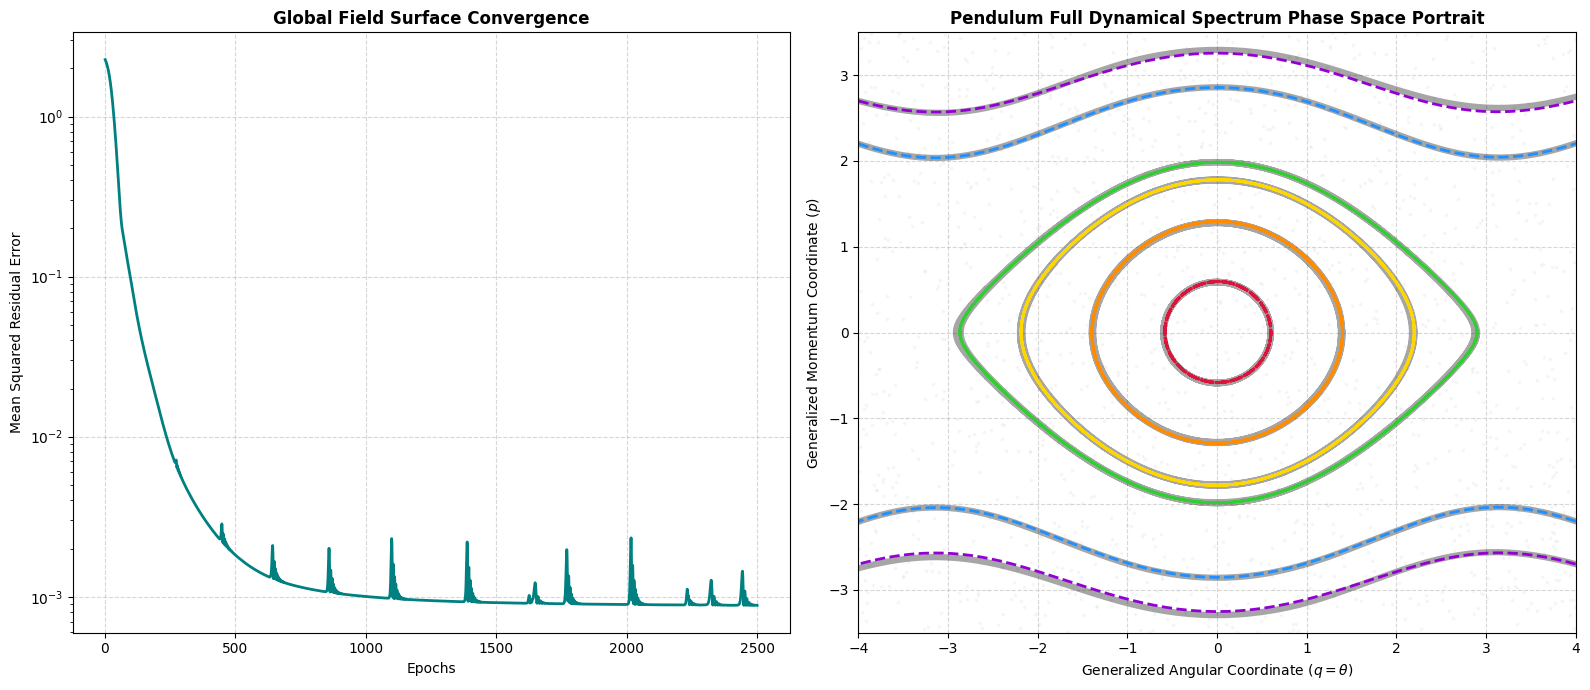

In [26]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. HARDWARE ACCELERATION SETUP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"HNN Spectrum Engine Target Device: {device}")

torch.manual_seed(42)
np.random.seed(42)

# =====================================================================
# 2. GENERATE GLOBAL PHASE SPACE TRAINING DATA
# =====================================================================
# Expanded domain to capture open circulation tracks (|p| > 2) and full angles
N = 1500
q_train = (torch.rand(N, 1, device=device) * 2.0 - 1.0) * 4.0  # q bounds: [-4.0, 4.0] rad
p_train = (torch.rand(N, 1, device=device) * 2.0 - 1.0) * 3.5  # p bounds: [-3.5, 3.5]
X = torch.cat([q_train, p_train], dim=1)

# Exact Simple Pendulum Vector Field
x_dot_true = torch.cat([X[:, [1]], -torch.sin(X[:, [0]])], dim=1)
x_dot_obs = x_dot_true + torch.randn_like(x_dot_true) * 0.03 # Moderate tracking noise

# =====================================================================
# 3. DEFINE THE HAMILTONIAN NEURAL NETWORK (HNN)
# =====================================================================
class HamiltonianNeuralNetwork(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def compute_energy(self, x):
        return self.mlp(x)

    def forward(self, x):
        x_spf = x.detach().clone().requires_grad_(True)
        energy = self.compute_energy(x_spf)

        # Spatial automatic differentiation
        dH_dx = torch.autograd.grad(
            outputs=energy, inputs=x_spf,
            grad_outputs=torch.ones_like(energy),
            create_graph=True, retain_graph=True, only_inputs=True
        )[0]

        # Symplectic transformation: dx/dt = [dH/dp, -dH/dq]
        return torch.cat([dH_dx[:, [1]], -dH_dx[:, [0]]], dim=1)

# Instantiation and optimization parameters
hnn_model = HamiltonianNeuralNetwork(input_dim=2, hidden_dim=64).to(device)
optimizer = torch.optim.Adam(hnn_model.parameters(), lr=1e-3)
epochs = 2500
loss_history = []

# =====================================================================
# 4. FIELD OPTIMIZATION LOOP
# =====================================================================
print("Mapping global non-linear energy surfaces...")
for epoch in range(epochs):
    x_dot_predicted = hnn_model(X)
    loss = torch.mean((x_dot_predicted - x_dot_obs) ** 2)
    loss_history.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch + 1:4d}/{epochs}] | Global Vector Field Loss: {loss.item():.6f}")

# =====================================================================
# 5. MULTI-LEVEL SPACE INTEGRATION SETUP (SCIPY RK45)
# =====================================================================
# 6 Initial Conditions chosen to reflect distinct physical energy regimes
initial_states = [
    [0.6, 0.0],    # Level 1: Small linear-like libration
    [1.4, 0.0],    # Level 2: Medium non-linear libration
    [2.2, 0.0],    # Level 3: Large non-linear libration
    [2.9, 0.0],    # Level 4: Near-separatrix critical boundary
    [-4.0, 2.2],   # Level 5: Lower open-loop continuous circulation (+)
    [-4.0, 2.7],    # Level 6: Higher open-loop continuous circulation (+)
    [4.0, -2.2],  # Level 7: Lower open-loop continuous circulation (-)
    [4.0, -2.7]   # Level 8: Higher open-loop continuous circulation (-)
]

t_span = (0.0, 50.0)
t_eval = np.linspace(t_span[0], t_span[1], 1200)

def true_pendulum_deriv(t, y):
    return [y[1], -np.sin(y[0])]

def hnn_scipy_deriv_wrapper(t, y):
    with torch.enable_grad():
        x_tensor = torch.tensor(y, dtype=torch.float32, device=device).reshape(1, 2)
        return hnn_model(x_tensor).detach().cpu().numpy().flatten()

# =====================================================================
# 6. DUAL PROFILE DIAGNOSTIC VISUALIZATION
# =====================================================================
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Left Plot: Convergence history
ax[0].plot(range(1, epochs+1), loss_history, color='teal', lw=2)
ax[0].set_title("Global Field Surface Convergence", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Mean Squared Residual Error")
ax[0].set_yscale('log')
ax[0].grid(True, linestyle='--', alpha=0.5)

# Right Plot: Full Spectral Level Lines Phase Space Portrait
ax[1].scatter(X[:, 0].cpu().numpy(), X[:, 1].cpu().numpy(), color='lightgray', s=2, alpha=0.15, label="Data Distribution Grid")

# Dynamic color tracking palette for distinct level displays
spectrum_colors = ['crimson', 'darkorange', 'gold', 'limegreen',
                   'dodgerblue', 'darkviolet', 'dodgerblue', 'darkviolet']

print("\nSimulating dynamical spectral lines via adaptive RK45 step integrations...")
for i, y0 in enumerate(initial_states):
    # Execute numerical standard integrations
    sol_true = solve_ivp(true_pendulum_deriv, t_span, y0, method='RK45', t_eval=t_eval)
    sol_hnn = solve_ivp(hnn_scipy_deriv_wrapper, t_span, y0, method='RK45', t_eval=t_eval, rtol=1e-6, atol=1e-9)

    # Extract structural state arrays
    q_t, p_t = sol_true.y[0, :], sol_true.y[1, :]
    q_h, p_h = sol_hnn.y[0, :], sol_hnn.y[1, :]

    # Ground-truth continuous skeletons
    ax[1].plot(q_t, p_t, color='black', alpha=0.35, lw=4.5,
               label="Analytical Reference" if i == 0 else "")
    # HNN Predicted geometric overlays
    ax[1].plot(q_h, p_h, color=spectrum_colors[i], linestyle='--', lw=2,
               label=f"HNN Orbit Profile {i+1}")

ax[1].set_title("Pendulum Full Dynamical Spectrum Phase Space Portrait", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Generalized Angular Coordinate ($q = \\theta$)")
ax[1].set_ylabel("Generalized Momentum Coordinate ($p$)")
ax[1].set_xlim([-4.0, 4.0])
ax[1].set_ylim([-3.5, 3.5])
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()